In [ ]:
# !pip install --upgrade --force-reinstall numpy==1.25.2
# !pip install --upgrade --force-reinstall gensim==4.3.2

# PADL coursework

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#from gensim.models import Word2Vec

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score, accuracy_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

import os
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from torch.utils.data import random_split

from skimage.metrics import structural_similarity as ssim

PROJECT_DIRECTORY = '/content/drive/MyDrive/padl_ws/'
DATA_DIRECTORY = PROJECT_DIRECTORY + "data/"
MODEL_DIRECTORY = PROJECT_DIRECTORY + "models/"

Mounted at /content/drive/


## Q1

### A

In [ ]:
# Get data from PADL-Q11-train.csv
data = np.loadtxt((DATA_DIRECTORY + '/PADL-Q11-train.csv'), delimiter=',', skiprows=1)
# Load header to get feature names
header = np.genfromtxt(DATA_DIRECTORY + '/PADL-Q11-train.csv', delimiter=',', max_rows=1, dtype=str)

# Split data into features and targets and feature names
X = data[:, :-1]
y = data[:, -1]
feature_names = header[:-1]

# Split the available data into training and validation we can be used to debug
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

# Create model
model_1a = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('reg', LinearRegression())
])

# Train model on training data
model_1a.fit(X_train, y_train)

y_val_pred = model_1a.predict(X_val)
print("R²:", r2_score(y_val, y_val_pred))

# Get coefficients
poly_feat_names = model_1a.named_steps['poly'].get_feature_names_out(input_features=feature_names)
coefs = np.hstack((model_1a.named_steps['reg'].intercept_, model_1a.named_steps['reg'].coef_))

print("\nCoefficients:")
print(f"{'Feature':>15s} | {'Coefficient':>12s}")
print("-" * 30)
print(f"{'(intercept)':>15s} | {coefs[0]:>12.6f}")
for name, coef in zip(poly_feat_names, coefs[1:]):
    print(f"{name:>15s} | {coef:>12.6f}")

In [ ]:
# Testing X_val_poly should be replaced with the unseen data
unseen = np.loadtxt("PADL-Q11-unseen.csv", delimiter=',', skiprows=1)
unseen_X = unseen[:, :-1]
unseen_y = unseen[:, -1]

y_pred = model_1a.predict(unseen_X)

print("R²:", r2_score(unseen_y, y_pred))


### B

In [ ]:
# Get data from PADL-Q12-train.csv
data = np.loadtxt((DATA_DIRECTORY + '/PADL-Q12-train.csv'), delimiter=',', skiprows=1)

# Split data into X and y
X = data[:, :-1]
y = data[:, -1]

# # Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.8)

# Train a linear regression model to act as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)
r2_lr = r2_score(y_val, y_pred_lr)

# Display the coefficients and R² for the generic Linear Regression model
print('Generic Linear Regression')
print(f"Coefficients: {lr_model.coef_}\nSum |coefficients|: {np.sum(np.abs(lr_model.coef_))}")
print(f"R²: {r2_lr:.4f}")

# Now with regularised models
# Define paramter space
alphas = np.logspace(-4, 2, 1000)
r2_threshold = 0.9 * r2_lr

# Initialise optimiation values
best_model = None
best_model_type = ''
best_alpha = None
best_r2 = -np.inf
lowest_coef_sum = np.inf

for alpha in alphas:
    # test L1 and L2 regression
    for model_type, model_class in [('Ridge', Ridge), ('Lasso', Lasso)]:
        model = model_class(alpha=alpha, max_iter=10000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        r2 = r2_score(y_val, y_pred)

        if r2 >= r2_threshold:
            coef_sum = np.sum(np.abs(model.coef_))
            if coef_sum < lowest_coef_sum:
                best_model = model
                best_model_type = model_type
                best_alpha = alpha
                best_r2 = r2
                lowest_coef_sum = coef_sum

print()
print('Regularised Model')
print(f"Model type: {best_model_type}")
print(f"Alpha: {best_alpha}")
print("Coefficients:", best_model.coef_)
print(f"Sum |coefficients|: {lowest_coef_sum:.4f}")
print(f"R²: {best_r2:.4f}")


In [ ]:
# Load unseen data
unseen_data = np.loadtxt('PADL-Q12-unseen.csv', delimiter=',', skiprows=1)
X_unseen = unseen_data[:, :-1]
y_unseen = unseen_data[:, -1]

# Predict using the best regularised model
y_unseen_pred = best_model.predict(X_unseen)

# Evaluate R² on unseen data
r2_unseen = r2_score(y_unseen, y_unseen_pred)
print(f"R² on unseen data: {r2_unseen:.4f}")

### C

In [ ]:
# Get data from PADL-Q13-train.csv
data = np.loadtxt((DATA_DIRECTORY + '/PADL-Q13-train.csv'), delimiter=',', skiprows=1)

# Split data into X and y
X = data[:, :-1]
y = data[:, -1]

# # Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

# Train a linear regression model to act as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)
r2_lr = r2_score(y_val, y_pred_lr)

# Use RFE for feature selection
rfe = RFE(lr_model, n_features_to_select=4)  # Select top 4 features (eliminate least useful feature)
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_val_rfe = rfe.transform(X_val)

# Train model on selected features
lr_model_rfe = LinearRegression()
lr_model_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = lr_model_rfe.predict(X_val_rfe)
r2_rfe = r2_score(y_val, y_pred_rfe)

# Display results
print(f"R² without preprocessing: {r2_lr:.4f}")
print(f"R² with feature selection (RFE): {r2_rfe:.4f}")


In [ ]:
# Load unseen data
unseen_data = np.loadtxt('PADL-Q13-unseen.csv', delimiter=',', skiprows=1)
X_unseen = unseen_data[:, :-1]
y_unseen = unseen_data[:, -1]

# Predict using the baseline model
y_unseen_pred_baseline = lr_model.predict(X_unseen)
y_unseen_pred_rfe = lr_model_rfe.predict(rfe.transform(X_unseen))

r2_unseen_baseline = r2_score(y_unseen, y_unseen_pred_baseline)
r2_unseen_rfe = r2_score(y_unseen, y_unseen_pred_rfe)

# Baseline
print(f"Baseline R² (all features): {r2_unseen_baseline:.4f}")
print(f"R² with RFE-selected features: {r2_unseen_rfe:.4f}")

## Q2

### A

In [ ]:
# Load data from PADL-Q2.csv
data = np.loadtxt((DATA_DIRECTORY + 'PADL-Q2.csv'), delimiter=',', skiprows=1)

# Extract into features and labels
X = data[:, :-1]
Y = data[:, -1]

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define number of clusters
num_clusters = len(np.unique(Y))

# K-means on original data
kmeans = KMeans(n_clusters=num_clusters)
Y_kmeans = kmeans.fit_predict(X_scaled)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Colour map
cmap = plt.cm.get_cmap('viridis', num_clusters)

# Create figure
plt.figure(figsize=(10,4))

# Plot 1: PCA with true labels
plt.subplot(1, 2, 1)
for i, label in enumerate(np.unique(Y)):
    color = cmap(i)
    plt.scatter(X_pca[Y == label, 0], X_pca[Y == label, 1],
                label=f'Class {int(label)}', c=[color], edgecolor='k', s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (True Labels)')
plt.legend(title='Class', fontsize=9)
plt.grid(True)

# Plot 2: PCA with K-means clusters
plt.subplot(1, 2, 2)
for i in range(num_clusters):
    color = cmap(i)
    plt.scatter(X_pca[Y_kmeans == i, 0], X_pca[Y_kmeans == i, 1],
                label=f'Cluster {i}', c=[color], edgecolor='k', s=60, marker='o')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (K-Means Clusters)')
plt.legend(title='Cluster', fontsize=9)
plt.grid(True)

### B

In [ ]:
# Apply K-means to PCA data
kmeans_pca = KMeans(n_clusters=num_clusters)
Y_kmeans_pca = kmeans_pca.fit_predict(X_pca)

# Plot predictions from kmeans after PCA
plt.figure(figsize=(6, 4))

for cluster in range(num_clusters):
    plt.scatter(X_pca[Y_kmeans_pca == cluster, 0], X_pca[Y_kmeans_pca == cluster, 1],
                label=f"Cluster {cluster}",c=[cmap(cluster)], edgecolor="k")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA-reduced Data")
plt.legend()
plt.show()

### C

In [ ]:
def clustering_accuracy(y_true, y_pred):
    # Build confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Solve the assignment problem (Hungarian algorithm)
    row_ind, col_ind = linear_sum_assignment(-cm)
    # Map predicted labels to best-matching true labels
    optimal_mapping = {old: new for old, new in zip(col_ind, row_ind)}
    mapped_preds = np.vectorize(optimal_mapping.get)(y_pred)
    # Return accuracy
    return accuracy_score(y_true, mapped_preds)

acc_full = clustering_accuracy(Y, Y_kmeans)
acc_pca = clustering_accuracy(Y, Y_kmeans_pca)
pca_variance = np.sum(pca.explained_variance_ratio_) * 100

print(f"Accuracy with all five features: {acc_full:.4f}")
print(f"Accuracy with PCA-reduced features: {acc_pca:.4f}")
print(f"Percentage of variance explained by PCA: {pca_variance:.2f}%")
print(f"Accuracy drop: {acc_full - acc_pca:.2%}")

## Q3

### A

In [ ]:
# Load data from PADL-Q3.txt
with open('datasets/PADL-Q3.txt', 'r') as f:
    sentences = [line.strip().split() for line in f]

# Train a Skip-gram Word2Vec model
skip_gram_model = Word2Vec(sentences=sentences, sg=1)
word_embeddings = skip_gram_model.wv

# Cosine similarities betweeen node 5 and nodes 21 - 30
print("Similarities with node 5:")
for i in range(21, 31):
    try:
        sim = word_embeddings.similarity("5", str(i))
        print(f"Node 5 <-> Node {i}: {sim:.4f}")
    except KeyError:
        print(f"Node {i} not in vocabulary.")


### B

## Q4

### A

### B

#### Data

In [ ]:
# Get data from body_measurements.csv
data = np.genfromtxt((DATA_DIRECTORY + 'body_measurements.csv'), delimiter=',', skip_header=1, filling_values=np.nan)

# Filter out nan values
valid_rows = ~np.isnan(data).any(axis=1)
data_clean = data[valid_rows]

# Split data into features and labels
X = data_clean[:, :-1]
y = data_clean[:, -1]

# Split into train and validation data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15)

poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)
X_test_poly = poly.transform(X_test)

# # Preprocesing
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_poly)
# X_val_scaled = scaler.transform(X_val_poly)
# X_test_scaled = scaler.transform(X_test_poly)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)



#### Model

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, size):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(size, size),
            nn.BatchNorm1d(size),
            nn.ReLU(),
        )

    def forward(self, x):
        return x + self.block(x)


class WaistPredictor(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(input_size, input_size),
            nn.Sigmoid()
        )

        self.input_layer = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )

        self.res_block1 = ResidualBlock(256)
        self.res_block2 = ResidualBlock(256)

        self.output_layer = nn.Linear(256, 1)

    def forward(self, x):
        x = x * self.attention(x)
        x = self.input_layer(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.output_layer(x)
        return

class FTTransformer(nn.Module):
    def __init__(self, input_size, emb_dim=64, n_heads=2, n_layers=1):
        super().__init__()
        self.bn_encoder = nn.BatchNorm1d(input_size)
        self.input_proj = nn.Linear(1, emb_dim)
        self.pos_emb = nn.Parameter(torch.randn(1, input_size, emb_dim))

        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=n_heads, batch_first=True, dropout=0.3)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.Linear(emb_dim, 1)
        )

    def forward(self, x):
        x = self.bn_encoder(x)
        x = self.input_proj(x.unsqueeze(-1))
        x = x + self.pos_emb  # [B, 6, emb_dim]
        x = self.transformer(x)  # [B, 6, emb_dim]
        x = x.mean(dim=1)        # mean-pool
        return self.mlp_head(x)


# Define model and training parameters
waist_predictor = FTTransformer(input_size=X_train_tensor.shape[1])
loss_function = nn.L1Loss()
optimiser = optim.AdamW(waist_predictor.parameters(), lr = 1e-3, weight_decay = 1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=50)

epochs = 1000
batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


#### Training and testing

Epoch 100, Train MAE: 524.59, Val MAE: 533.44, lr 0.001
Epoch 200, Train MAE: 40.08, Val MAE: 44.58, lr 0.001
Epoch 300, Train MAE: 33.53, Val MAE: 35.16, lr 0.001
Early stopping
Final MAE on the validation set: 32.82


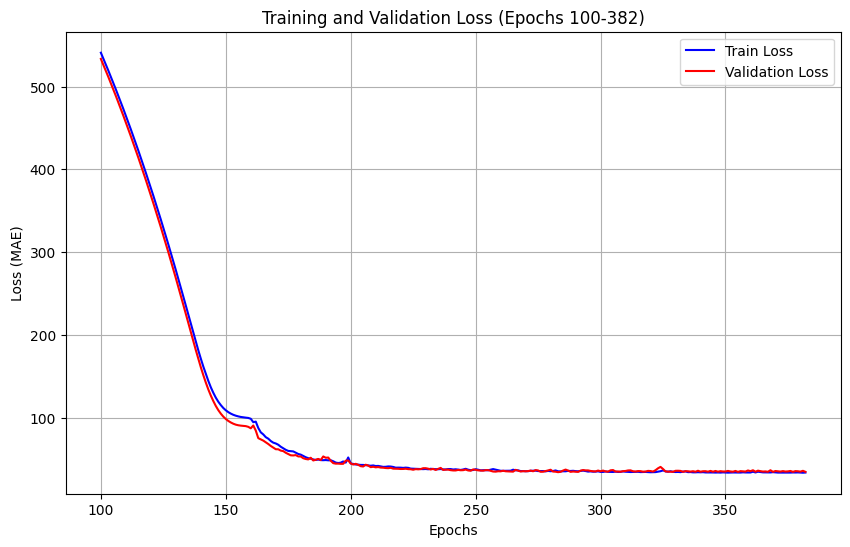

In [ ]:
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 100
patience_counter = 0
end_epoch = 1000

# Training loop
for epoch in range(epochs):
    total_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimiser.zero_grad()
        predictions = waist_predictor(batch_X)
        loss = loss_function(predictions, batch_y)
        loss.backward()
        optimiser.step()
        total_train_loss += loss.item() * batch_X.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Validation
    waist_predictor.eval()
    with torch.no_grad():
        val_preds = waist_predictor(X_val_tensor)
        val_loss = loss_function(val_preds, y_val_tensor).item()
        val_mae = mean_absolute_error(y_val, val_preds.numpy())  # Real-world MAE

    val_losses.append(val_loss)
    scheduler.step(val_loss)

    current_lr = scheduler.optimizer.param_groups[0]['lr']

    if (epoch+1)%100 == 0:
        print(f"Epoch {epoch+1}, Train MAE: {loss:.2f}, Val MAE: {val_loss:.2f}, lr {current_lr}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(waist_predictor.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping")
            end_epoch = epoch
            break

# Switch to evaluation mode
waist_predictor.eval()
with torch.no_grad():
    # Get predictions on the scaled validation data
    y_test_pred = waist_predictor(X_test_tensor).detach().numpy()

# Calculate the MAE in the original scale using sklearn's mean_absolute_error
final_mae = mean_absolute_error(y_test_tensor, y_test_pred)
print(f"Final MAE on the validation set: {final_mae:.2f}")

# Plot training and validation loss from epoch 100 to 1000
start_epoch = 100
end_epoch = min(1000, end_epoch)

plt.figure(figsize=(10, 6))
plt.plot(range(start_epoch, end_epoch + 1), train_losses[start_epoch - 1:end_epoch], label="Train Loss", color='blue')
plt.plot(range(start_epoch, end_epoch + 1), val_losses[start_epoch - 1:end_epoch], label="Validation Loss", color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss (MAE)')
plt.title(f'Training and Validation Loss (Epochs {start_epoch}-{end_epoch})')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# torch.save(waist_predictor.state_dict(), MODEL_DIRECTORY + "/waist_preictor_temp.pth")

In [ ]:
file_size = os.path.getsize('best_model.pth')
print(f"Model size: {file_size} bytes")
print(f"Model size: {file_size / (1024**2)} MB") # in MB

Model size: 562018 bytes
Model size: 0.5359821319580078 MB


## Q5

### A

### B

#### Data

In [ ]:
dataset_path = DATA_DIRECTORY + 'garment_images'
labels_csv = DATA_DIRECTORY + 'garment_images/train_labels.csv'

class GarmentImageDataset(Dataset):
    def __init__(self, root_dir, labels_csv, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.labels_df = pd.read_csv(labels_csv)
        self.image_paths = []
        self.labels = []

        for folder_name in os.listdir(root_dir):
            folder_path = os.path.join(root_dir, folder_name)
            if os.path.isdir(folder_path):
                label = int(folder_name)
                for filename in os.listdir(folder_path):
                    if filename.endswith(".jpg"):
                        image_path = os.path.join(folder_path, filename)
                        self.image_paths.append(image_path)
                        self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class TransformedDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# Original dataset without transform
base_dataset = GarmentImageDataset(dataset_path, labels_csv)

# Shuffle and split
indices = torch.randperm(len(base_dataset)).tolist()
train_size = int(0.8 * len(base_dataset))
val_size = int(0.1 * len(base_dataset))
test_size = len(base_dataset) - train_size - val_size

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

train_subset = torch.utils.data.Subset(base_dataset, train_indices)
val_subset = torch.utils.data.Subset(base_dataset, val_indices)
test_subset = torch.utils.data.Subset(base_dataset, test_indices)

# Wrap each subset with a transform
train_dataset = TransformedDataset(train_subset, train_transform)
val_dataset = TransformedDataset(val_subset, test_transform)
test_dataset = TransformedDataset(test_subset, test_transform)


In [ ]:
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class SEBlock(nn.Module):
    def __init__(self, in_ch, se_ratio=0.25):
        super().__init__()
        squeezed = max(1, int(in_ch * se_ratio))
        self.fc1 = nn.Conv2d(in_ch, squeezed, 1, bias=False)
        self.fc2 = nn.Conv2d(squeezed, in_ch, 1, bias=False)
    def forward(self, x):
        scale = F.adaptive_avg_pool2d(x, 1)
        scale = F.relu(self.fc1(scale))
        scale = torch.sigmoid(self.fc2(scale))
        return x * scale

class MBConv(nn.Module):
    def __init__(self, in_ch, out_ch, expand_ratio, stride):
        super().__init__()
        mid_ch = in_ch * expand_ratio
        self.use_res = (in_ch == out_ch and stride == 1)
        self.block = nn.Sequential(
            # 1×1 expansion
            nn.Conv2d(in_ch, mid_ch, 1, bias=False),
            nn.BatchNorm2d(mid_ch),
            Swish(),
            # 3×3 depthwise
            nn.Conv2d(mid_ch, mid_ch, 3, stride, 1, groups=mid_ch, bias=False),
            nn.BatchNorm2d(mid_ch),
            Swish(),
            # SE
            SEBlock(mid_ch),
            # 1×1 projection
            nn.Conv2d(mid_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        )

    def forward(self, x):
        out = self.block(x)
        return x + out if self.use_res else out


class EfficientNetE1(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            Swish()
        )

        # (in_ch, out_ch, expand_ratio, stride, repeats)
        cfgs = [
            (32,  16, 1, 1, 1),
            (16,  24, 6, 2, 1),
            (24,  40, 6, 2, 1),
            (40,  80, 6, 2, 2),
            (80, 112, 6, 1, 2),
            (112,192, 6, 2, 3),
            (192,320, 6, 1, 1)
        ]

        layers = []
        in_ch = 32
        for (c_in, c_out, exp, stride, n) in cfgs:
            for i in range(n):
                s = stride if i == 0 else 1
                layers.append(MBConv(in_ch, c_out, exp, s))
                in_ch = c_out
        self.blocks = nn.Sequential(*layers)

        self.head = nn.Sequential(
            nn.Conv2d(in_ch, 512, 1, bias=False),
            nn.BatchNorm2d(512),
            Swish(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        return self.head(x)

#### Model and Params

In [ ]:
class FashionClassifier(nn.Module):
    def __init__(self):
        super(FashionClassifier, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        return self.classifier(x)

# Hyperparameters
learning_rate = 1e-4
epochs = 30
batch_size = 64

# Device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Instantiate model, loss function, and optimizer
fashion_classifier = EfficientNetE1().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(fashion_classifier.parameters(), lr=learning_rate, weight_decay=1e-4)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


cuda


#### Training

In [ ]:
# Training loop
fashion_classifier.train()
correct, total = 0, 0

# Lists to store loss and accuracy values for plotting
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training and validation loop
for epoch in range(epochs):

    # Train the model
    fashion_classifier.train()
    train_correct, train_total = 0, 0
    running_loss = 0.0
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = fashion_classifier(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_total += labels.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / train_total
    avg_train_loss = running_loss / len(train_dataloader)

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%", end='')


    # Validate the model
    fashion_classifier.eval()
    val_correct, val_total = 0, 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = fashion_classifier(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            val_total += labels.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total
    avg_val_loss = val_loss / len(val_dataloader)

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    print(f" - Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

    print('-' * 50)

Epoch [1/30] - Train Loss: 0.9862, Train Accuracy: 49.88% - Validation Loss: 1.1139, Validation Accuracy: 24.81%
--------------------------------------------------
Epoch [2/30] - Train Loss: 0.6881, Train Accuracy: 66.30% - Validation Loss: 0.6452, Validation Accuracy: 67.18%
--------------------------------------------------
Epoch [3/30] - Train Loss: 0.5480, Train Accuracy: 76.68% - Validation Loss: 0.4515, Validation Accuracy: 81.68%
--------------------------------------------------
Epoch [4/30] - Train Loss: 0.4486, Train Accuracy: 81.87% - Validation Loss: 0.4082, Validation Accuracy: 84.73%
--------------------------------------------------
Epoch [5/30] - Train Loss: 0.3619, Train Accuracy: 85.86% - Validation Loss: 0.2973, Validation Accuracy: 87.02%
--------------------------------------------------
Epoch [6/30] - Train Loss: 0.3069, Train Accuracy: 88.34% - Validation Loss: 0.2607, Validation Accuracy: 88.55%
--------------------------------------------------
Epoch [7/30] - T

#### Eval

Test Loss: 0.2208, Test Accuracy: 92.80%


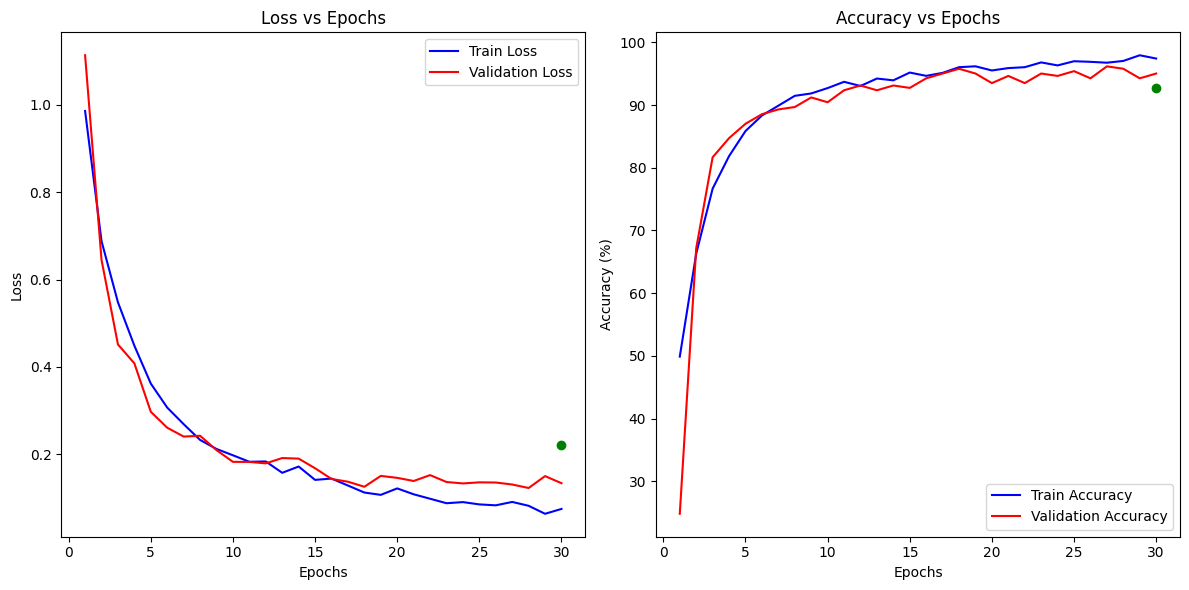

In [ ]:
fashion_classifier.eval()
test_correct, test_total = 0, 0
test_loss = 0.0
with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)

        outputs = fashion_classifier(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total
average_test_loss = test_loss / len(test_dataloader)


print(f"Test Loss: {average_test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")


# Plot Loss vs Epochs
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", color="blue")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", color="red")
plt.plot(len(train_losses), average_test_loss, 'go')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()

# Plot Accuracy vs Epochs
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label="Train Accuracy", color="blue")
plt.plot(range(1, len(val_losses) + 1), val_accuracies, label="Validation Accuracy", color="red")
plt.plot(len(train_accuracies), test_accuracy, 'go')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Epochs")
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

In [ ]:
torch.save(fashion_classifier.state_dict(), MODEL_DIRECTORY + "/fashion_classifier_temp.pth")

In [ ]:
file_size = os.path.getsize(MODEL_DIRECTORY + 'fashion_classifier_temp.pth')
print(f"Model size: {file_size} bytes")
print(f"Model size: {file_size / (1024**2)} MB") # in MB

Model size: 20239934 bytes
Model size: 19.302305221557617 MB


In [ ]:
torch.save(fashion_classifier.state_dict(), MODEL_DIRECTORY + "/fashion_classifier.pth")

## Q6

### A

### B

### C

#### Data

In [23]:
dataset_path = DATA_DIRECTORY + "/face_images"

class FaceDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform or transforms.Compose([
            transforms.ToTensor()
        ])
        self.image_paths = [os.path.join(data_dir, fname) for fname in os.listdir(data_dir)]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('L')  # Convert to grayscale
        if self.transform:
            image = self.transform(image)
        return image

# Define split sizes
total_size = len(os.listdir(dataset_path))
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size  # Ensure total adds up

# Load the full dataset
full_dataset = FaceDataset(data_dir=dataset_path)

# Split into train, validation, and test
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

#### Autoencoder and Functions

In [24]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.convolutions = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),  # 192x160 → 96x80
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 96x80 → 48x40
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  # 48x40 → 24x20
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),  # 24x20 → 12x10
            nn.ReLU(),
        )
        self.fc = nn.Linear(256 * 12 * 10, 32)

    def forward(self, x):
        x = self.convolutions(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(32, 256 * 12 * 10)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 12x10 → 24x20
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 24x20 → 48x40
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 48x40 → 96x80
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),  # 96x80 → 192x160
            nn.Sigmoid(),  # Match input range (0, 1)
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), 256, 12, 10)
        return self.deconv(x)

# Loss function (MSE loss)
def mse_loss(output, target):
    return F.mse_loss(output, target)

def ssim_score(image1, image2):
    image1 = image1.squeeze().detach().cpu().numpy()
    image2 = image2.squeeze().detach().cpu().numpy()
    return ssim(image1, image2, data_range=1.0)

def plot_images(original, reconstructed):
    # Ensure the image is in the correct range [0, 1]
    reconstructed = torch.clamp(reconstructed, 0, 1)  # Clamping reconstructed values to the range [0, 1]

    # Convert to NumPy and squeeze batch dimension
    original = original.squeeze().cpu().detach().numpy()
    reconstructed = reconstructed.squeeze().cpu().detach().numpy()

    # Plotting the original and reconstructed images
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(reconstructed, cmap='gray')
    axes[1].set_title('Reconstructed Image')
    axes[1].axis('off')

    plt.show()

encoder = Encoder()
decoder = Decoder()

#### Training

In [ ]:
learning_rate = 1e-3
batch_size = 64
epochs = 20

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=learning_rate)

train_losses = []
val_losses = []
train_ssims = []
val_ssims = []
best_val_ssim = 0.0
temp_model_path = MODEL_DIRECTORY + "temp_autoencoder.pth"

# Start training and validation loop
for epoch in range(epochs):
    encoder.train()
    decoder.train()

    running_loss = 0.0
    running_ssim = 0.0

    # Training loop
    for i, images in enumerate(train_loader):

        optimizer.zero_grad()  # Zero the gradients

        # Forward pass: encode and decode
        latents = encoder(images)
        reconstructed_images = decoder(latents)

        # Compute MSE loss
        loss = mse_loss(reconstructed_images, images)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Compute SSIM loss for validation
        ssim_value = ssim_score(reconstructed_images, images)

        # Accumulate loss and SSIM values for averaging
        running_loss += loss.item()
        running_ssim += ssim_value

    # Average loss and SSIM for this epoch
    avg_loss = running_loss / len(train_loader)
    avg_ssim = running_ssim / len(train_loader)

    # Print training statistics
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, SSIM: {avg_ssim:.4f}", end='')

    # Validation after each epoch (same as the training loop, but without gradients)
    encoder.eval()
    decoder.eval()

    running_val_loss = 0.0
    running_ssim_val = 0.0
    with torch.no_grad():
        for images in val_loader:
            latents = encoder(images)
            reconstructed_images = decoder(latents)

            val_loss = mse_loss(reconstructed_images, images)
            running_val_loss += val_loss.item()

            ssim_value = ssim_score(reconstructed_images, images)
            running_ssim_val += ssim_value

    avg_val_loss = running_val_loss / len(val_loader)
    avg_ssim_val = running_ssim_val / len(val_loader)

    # Average SSIM for validation set
    avg_ssim_val = running_ssim_val / len(val_loader)

    # Print validation statistics
    print(f", Validation Loss: {avg_val_loss:.4f}, SSIM: {avg_ssim_val:.4f}")

    if avg_ssim_val > best_val_ssim:
      best_val_ssim = avg_ssim_val
      torch.save({
          'encoder_state_dict': encoder.state_dict(),
          'decoder_state_dict': decoder.state_dict(),
      }, temp_model_path)
      print("Best model saved!")

    train_losses.append(avg_loss)
    val_losses.append(avg_val_loss)
    train_ssims.append(avg_ssim)
    val_ssims.append(avg_ssim_val)

Epoch [1/20], Loss: 0.0174, SSIM: 0.8371, Validation Loss: 0.0072, SSIM: 0.9096
Best model saved!
Epoch [2/20], Loss: 0.0056, SSIM: 0.9291, Validation Loss: 0.0049, SSIM: 0.9364
Best model saved!


#### Evaluation

Test Loss: 0.0038303633336909115, SSIM: 0.9480


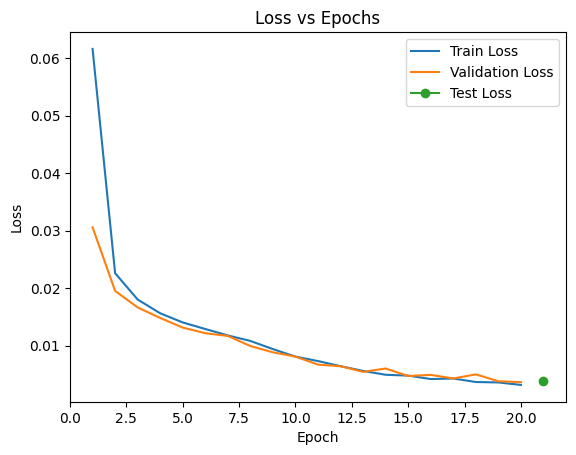

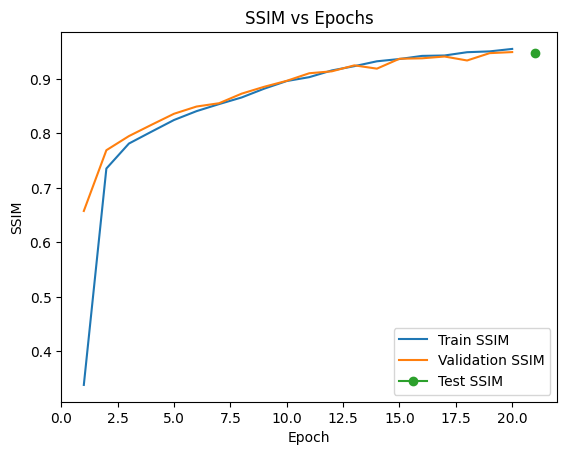

In [26]:
encoder.eval()
decoder.eval()
running_ssim_test = 0.0
running_test_loss = 0.0
with torch.no_grad():
  for images in test_loader:

    # Forward pass
    latents = encoder(images)
    reconstructed_images = decoder(latents)

    test_loss = mse_loss(reconstructed_images, images)
    running_test_loss += test_loss.item()

    # Compute SSIM loss for validation
    ssim_value = ssim_score(reconstructed_images, images)
    running_ssim_test += ssim_value

# Average SSIM for validation set
avg_ssim_test = running_ssim_test / len(test_loader)
avg_test_loss = running_test_loss / len(test_loader)

# Print validation statistics
print(f"Test Loss: {avg_test_loss}, SSIM: {avg_ssim_test:.4f}")

# ——— Plot Loss vs Epochs ———
plt.figure()
plt.plot(range(1, len(train_losses)  + 1), train_losses,    label="Train Loss")
plt.plot(range(1, len(val_losses)    + 1), val_losses,      label="Validation Loss")
plt.plot(len(train_losses) + 1, avg_test_loss,              marker='o', label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()

# ——— Plot SSIM vs Epochs ———
plt.figure()
plt.plot(range(1, len(train_ssims)   + 1), train_ssims,     label="Train SSIM")
plt.plot(range(1, len(val_ssims)     + 1), val_ssims,       label="Validation SSIM")
plt.plot(len(train_ssims) + 1, avg_ssim_test,               marker='o', label="Test SSIM")
plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.title("SSIM vs Epochs")
plt.legend()
plt.show()

In [27]:
autoencoder_size = os.path.getsize(temp_model_path) / (1024 * 1024)  # bytes → MiB
print(f"Total size: {autoencoder_size:.2f} MiB")

Total size: 12.88 MiB


In [28]:
# torch.save({'encoder_state_dict': encoder.state_dict(), 'decoder_state_dict': decoder.state_dict(),}, MODEL_DIRECTORY + 'autoencoder.pth')